In [38]:
cd "C:\Users\jasmineyeo\Documents\GitHub\V1_SpatialModulation"

C:\Users\jasmineyeo\Documents\GitHub\V1_SpatialModulation


In [39]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from tqdm import tqdm

from helper import TwoP 

In [ ]:
import os

# find the number of subfolders in the folder
folder_path = r'D:\inyoung\#1_d90_JSY'
subfolders = [f.path for f in os.scandir(folder_path) if f.is_dir()]
num_subfolders = len(subfolders)

# initialize the lists to store the basefolder and rec_names
basefolder = []
rec_names = []

# loop through the subfolders to calculate dFF and plot the spikes
for subfolder in subfolders:
    basepath = subfolder
    rec_name = os.path.basename(subfolder)
    
    # calculate dFF
    twop_data = TwoP(basepath, rec_name)
    
    twop_data.find_files()
    twop_dict = twop_data.calc_dFF()
    
    s2p_spikes= twop_dict['s2p_spks'].copy()
    cell_num = np.size(s2p_spikes, 0)
    # print(s2p_spikes.shape)
    # print(np.size(s2p_spikes, 1))
    
    norm_s2p_spikes = np.zeros(s2p_spikes.shape)
    
    # normalize the spikes for each cell
    for i in range(cell_num):
        s2p_spikes_min = np.min(s2p_spikes[i])
        s2p_spikes_max = np.max(s2p_spikes[i])
        norm_s2p_spikes[i] = (s2p_spikes[i] - s2p_spikes_min) / (s2p_spikes_max - s2p_spikes_min)
    
    # plot the spikes (original and normalized)
    fig, axs = plt.subplots(1, 2, figsize=(20, 6))
    
    im0 = axs[0].imshow(s2p_spikes, aspect='auto', cmap='hot', interpolation='nearest')
    axs[0].set_title(f'Spikes for {rec_name}')
    axs[0].set_xlabel('Frames')
    axs[0].set_ylabel('Cells')
    fig.colorbar(im0, ax=axs[0], label='spikes')
    
    im1 = axs[1].imshow(norm_s2p_spikes, aspect='auto', cmap='hot', interpolation='nearest')
    axs[1].set_title(f'Normalized spikes for {rec_name}')
    axs[1].set_xlabel('Frames')
    axs[1].set_ylabel('Cells')
    fig.colorbar(im1, ax=axs[1], label='normalized spikes')
    
    plt.show()
    
    fig.savefig(os.path.join(basepath, rec_name + '_spikes.jpg'))

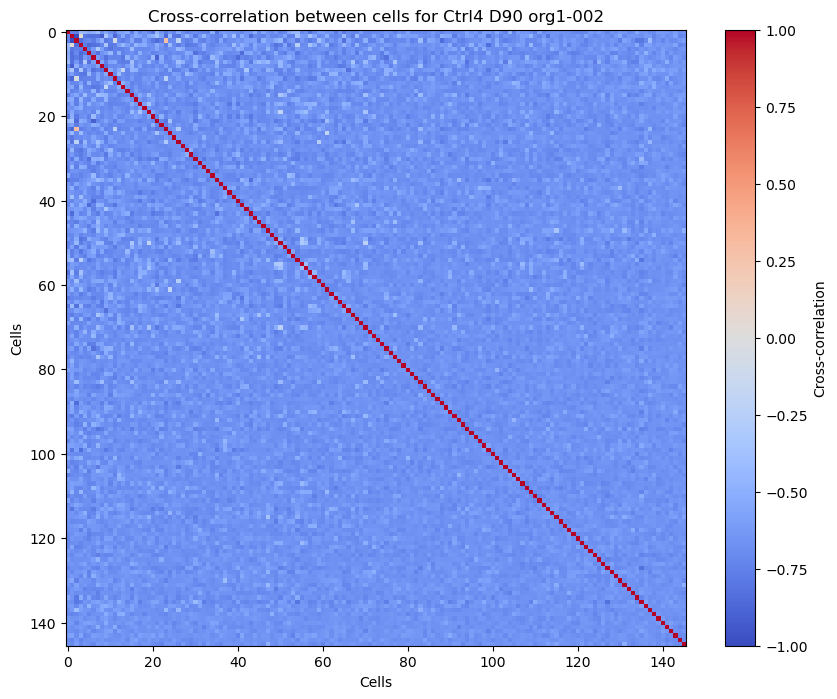

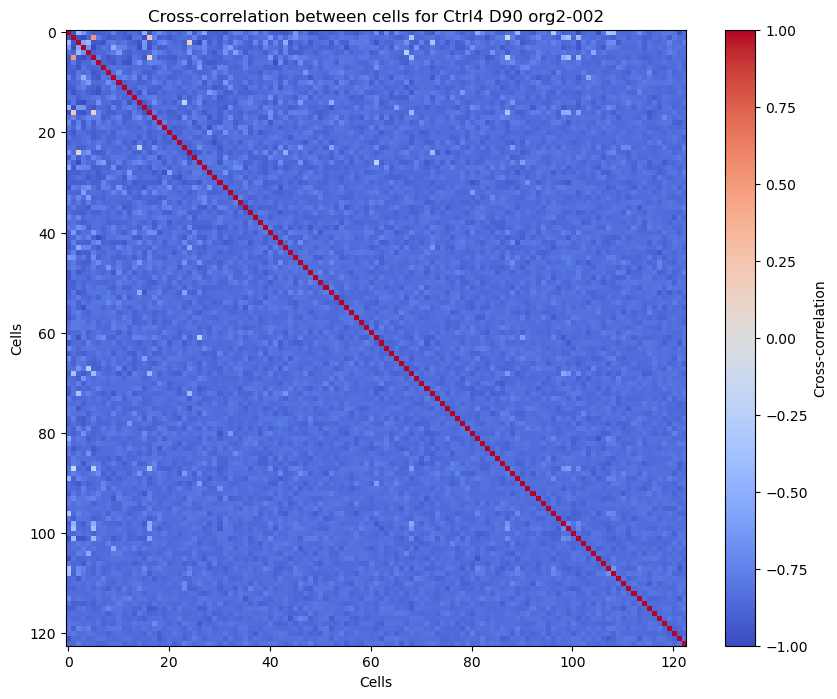

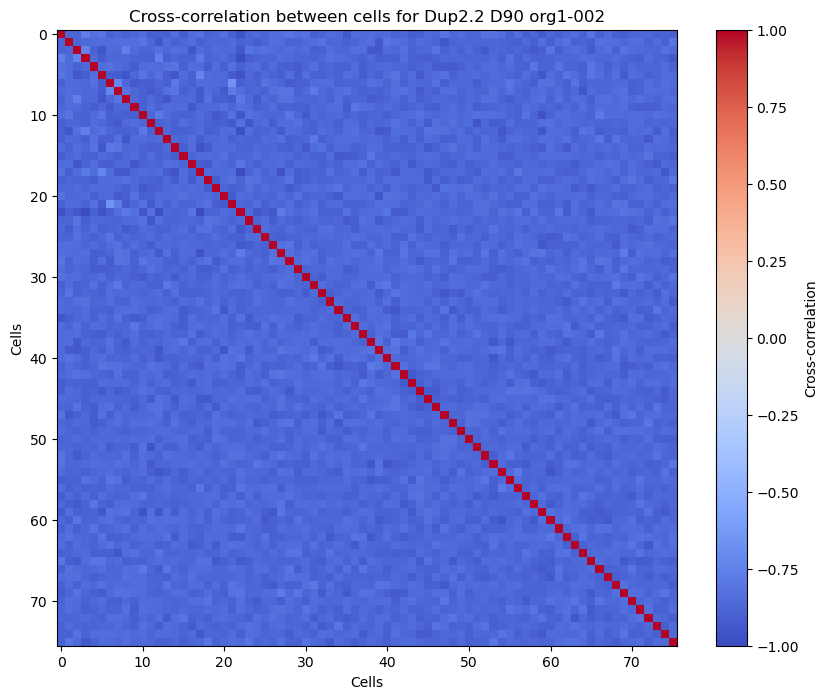

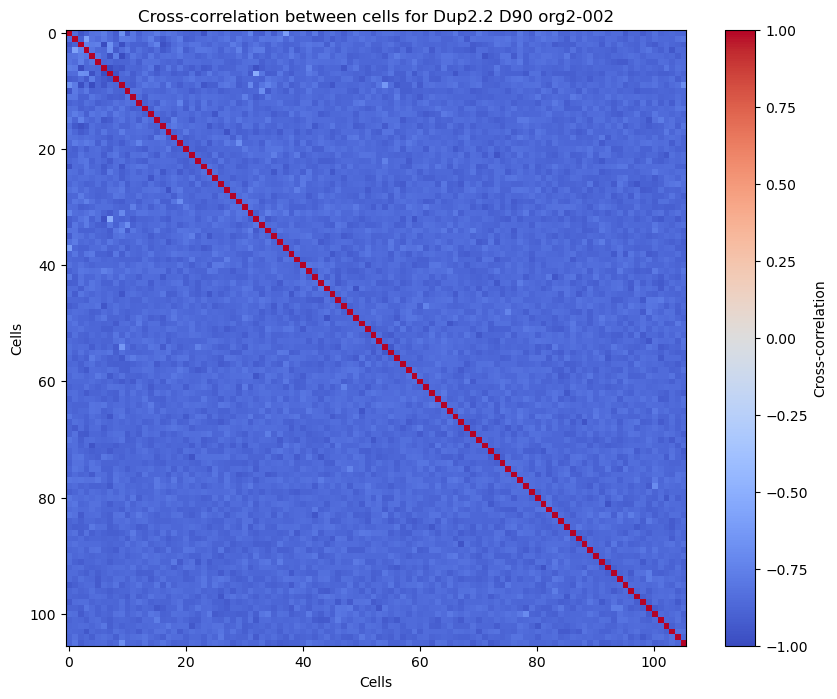

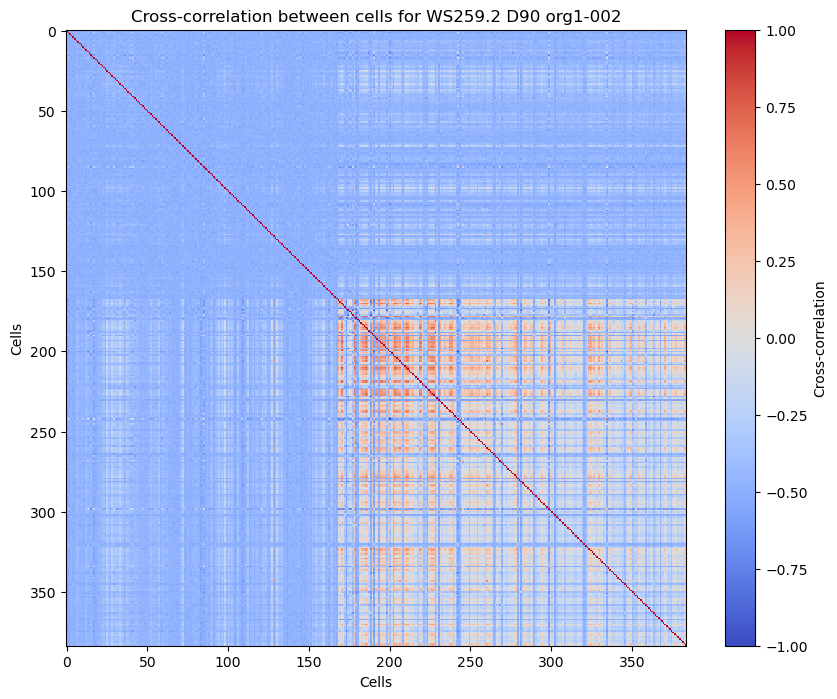

C:\Users\jasmineyeo\Documents\GitHub\V1_SpatialModulation\helper\twop.py:89: RuntimeWarning: invalid value encountered in divide
  _raw_dFF = (F_cell - _f0_raw) / _f0_raw * 100


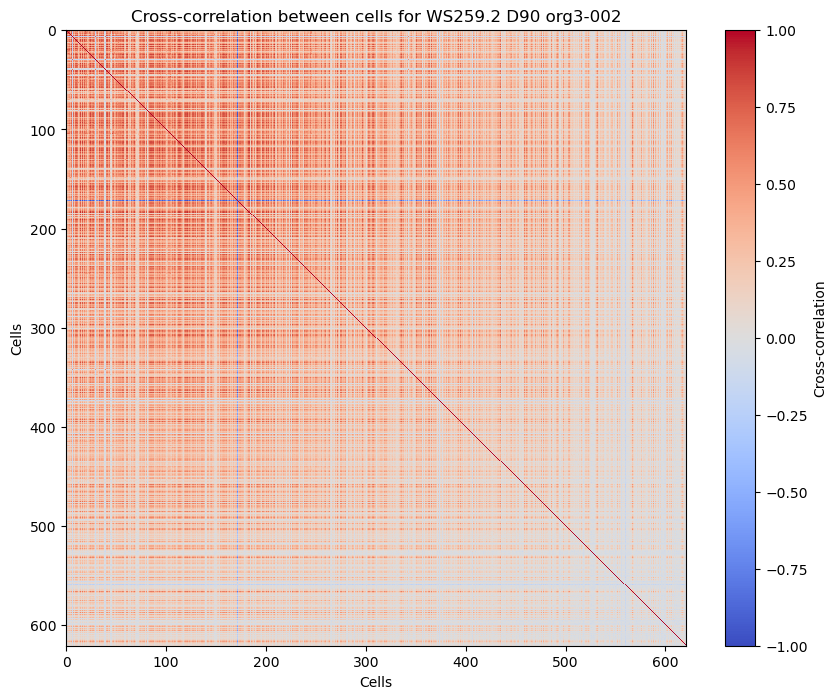

In [40]:
import numpy as np

def normalize_crosscorr(C):
    """
    Normalize a 2D cross-correlation matrix to range [-1, 1].
    
    Parameters:
        C (numpy.ndarray): Input 2D correlation matrix.
    Returns:
        numpy.ndarray: Normalized correlation matrix.
    """
    C_min = np.min(C)
    C_max = np.max(C)
    
    # Avoid division by zero if the matrix is constant
    if C_max == C_min:
        return np.zeros_like(C)
    
    C_norm = ((C - C_min) / (C_max - C_min)) * 2 - 1
    return C_norm

# calculate cross-correlation between cells (to test for synchronicity between cells)
for subfolder in subfolders:
    basepath = subfolder
    rec_name = os.path.basename(subfolder)
    
    # calculate dFF
    twop_data = TwoP(basepath, rec_name)
    
    twop_data.find_files()
    twop_dict = twop_data.calc_dFF()
    
    norm_dFF = twop_dict['norm_dFF']
    cell_num = norm_dFF.shape[0]
    
    # calculate cross-correlation matrix
    cross_corr_matrix = np.corrcoef(norm_dFF)
    norm_cross_matrix = normalize_crosscorr(cross_corr_matrix)
    
    # plot the cross-correlation matrix
    plt.figure(figsize=(10, 8))
    plt.imshow(norm_cross_matrix, aspect='auto', cmap='coolwarm', interpolation='nearest')
    plt.colorbar(label='Cross-correlation')
    plt.title(f'Cross-correlation between cells for {rec_name}')
    plt.xlabel('Cells')
    plt.ylabel('Cells')
    # save the plot
    plt.savefig(os.path.join(basepath, rec_name + '_cross_correlation.jpg'))
    
    plt.show()
    plt.close()
    


In [ ]:
### maybe needed for entire population?
# Calculate the average correlation value for each cell
avg_corr_values = np.mean(norm_cross_matrix, axis=1)
std_corr_values = np.std(norm_cross_matrix, axis=1)

# Calculate the overall average and standard deviation
overall_avg = np.mean(avg_corr_values)
overall_std = np.std(avg_corr_values)

# Create the scatter plot
plt.figure(figsize=(10, 6))
plt.scatter(range(cell_num), avg_corr_values, label='Average Correlation per Cell')
plt.errorbar(range(cell_num), avg_corr_values, yerr=std_corr_values, fmt='o', alpha=0.5)

# Plot the overall average with standard deviation bar
plt.axhline(overall_avg, color='r', linestyle='--', label=f'Overall Average: {overall_avg:.2f}')
plt.fill_between(range(cell_num), overall_avg - overall_std, overall_avg + overall_std, color='r', alpha=0.2, label=f'Standard Deviation: {overall_std:.2f}')

plt.xlabel('Cell Index')
plt.ylabel('Average Correlation')
plt.title('Average Correlation per Cell with Standard Deviation')
plt.legend()
plt.show()